# Actividad práctica: contraste de hipótesis y regresión logística

**Estudiante:** Daniel Alfonso Rozo Briceño  
**Programa:** Ciencia de datos, programación para ciencia de datos II  
**Institución:** Fundación Universitaria Comenzar  
**Fecha:** Agosto de 2026

## Introducción

El presente trabajo amplía el análisis exploratorio desarrollado en el taller anterior, en el que se estudió la relación entre las horas semanales de estudio independiente y el puntaje obtenido en un examen final. En esta nueva etapa se utilizan herramientas de estadística computacional para contrastar formalmente una hipótesis, estimar relaciones mediante regresión lineal múltiple y construir un clasificador binario mediante regresión logística.

La pregunta de investigación que orienta el análisis es: **¿de qué manera el número de horas semanales de estudio independiente se relaciona con el puntaje obtenido en el examen final por estudiantes de asignaturas cuantitativas de educación superior?**. El contraste de hipótesis se realiza mediante `scipy.stats.linregress`, función que devuelve la pendiente estimada, el estadístico de prueba y el valor p para evaluar si existe una relación lineal [3]. Para la regresión lineal se emplea `LinearRegression`, que ajusta los coeficientes minimizando la suma de cuadrados de los residuos [1]. Para la clasificación se usa `LogisticRegression`, cuyo resultado principal es una probabilidad estimada que luego se transforma en una clase mediante un umbral [2].

La base de datos procede del taller anterior y fue generada de forma reproducible con una semilla fija. Por tanto, sus resultados sirven para demostrar el procedimiento computacional y no deben interpretarse como evidencia generalizable sobre una población real. Además, como la base original solo contiene una variable explicativa observada, se incorporan las transformaciones cuadrática y cúbica de las horas de estudio en la regresión lineal múltiple. Esta decisión permite cumplir el requisito operativo de utilizar tres características continuas, pero se reporta con transparencia que no son tres mediciones independientes.

## Objetivos

### Objetivo general

Aplicar contraste de hipótesis, regresión lineal múltiple y regresión logística con Python para analizar la relación entre las horas de estudio y el desempeño académico, documentando el proceso, los resultados y sus limitaciones.

### Objetivos específicos

1. Formular hipótesis nula y alternativa mutuamente excluyentes y verificarlas con un contraste bilateral de la pendiente.
2. Ajustar una regresión lineal múltiple con una división de entrenamiento del 70 % y evaluar sus predicciones mediante MSE y R².
3. Crear una variable binaria de desempeño, comparar distintos valores de `C` y algoritmos `solver`, y evaluar el clasificador mediante precisión, sensibilidad, especificidad y matriz de confusión.
4. Interpretar los resultados en el contexto educativo y proponer una prueba o mejora posterior.

## Lista de figuras y tablas

**Figuras.** Figura 1. Distribuciones univariadas. Figura 2. Relación exploratoria entre estudio y puntaje. Figura 3. Recta estimada para el contraste. Figura 4. Diagnóstico de la regresión lineal múltiple. Figura 5. Probabilidad logística de aprobación. Figura 6. Matriz de confusión.

**Tablas.** Tabla 1. Resumen descriptivo de las variables. Tabla 2. Comparación de configuraciones de regresión logística.

## 1. Preparación del entorno y generación reproducible de los datos

La semilla aleatoria permite que cualquier persona pueda ejecutar nuevamente el Notebook y obtener la misma muestra de 100 observaciones. La base se conserva en un archivo CSV como soporte del análisis.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
ALPHA = 0.05
OUTPUT_DIR = Path('figuras')
OUTPUT_DIR.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

np.random.seed(RANDOM_STATE)
n_estudiantes = 100
horas_estudio = np.random.normal(loc=12.0, scale=3.5, size=n_estudiantes)
horas_estudio = np.clip(horas_estudio, 2.0, 25.0)

puntaje_examen = 35 + 3.2 * horas_estudio + np.random.normal(
    loc=0.0, scale=5.0, size=n_estudiantes
)
puntaje_examen = np.clip(puntaje_examen, 0.0, 100.0)

df_estudiantes = pd.DataFrame({
    'Horas_Estudio_Semana': horas_estudio,
    'Puntaje_Examen': puntaje_examen
})

df_estudiantes.to_csv('datos_estudiantes.csv', index=False)
print(f'Muestra generada: {df_estudiantes.shape[0]} estudiantes y {df_estudiantes.shape[1]} variables originales.')
df_estudiantes.head()

Muestra generada: 100 estudiantes y 2 variables originales.


,Horas_Estudio_Semana,Puntaje_Examen
0,13.738500,71.886345
1,11.516075,69.748213
2,14.266910,78.940539
3,17.330604,86.446548
4,11.180463,69.971054


## 2. Revisión descriptiva y visualización exploratoria

La estadística descriptiva permite verificar la escala de las variables antes de aplicar modelos. La media resume el centro de los datos, mientras que la desviación estándar informa sobre su dispersión. También se revisan los valores mínimo y máximo para comprobar que se encuentren en rangos coherentes.

In [2]:
resumen = df_estudiantes.describe().T
resumen = resumen[['count', 'mean', '50%', 'std', 'min', 'max']].rename(columns={
    'count': 'n', 'mean': 'media', '50%': 'mediana', 'std': 'desv_est',
    'min': 'mínimo', 'max': 'máximo'
})
resumen.round(2)

,n,media,mediana,desv_est,mínimo,máximo
Horas_Estudio_Semana,100.0,11.64,11.56,3.18,2.83,18.48
Puntaje_Examen,100.0,72.34,71.70,10.61,45.44,100.00


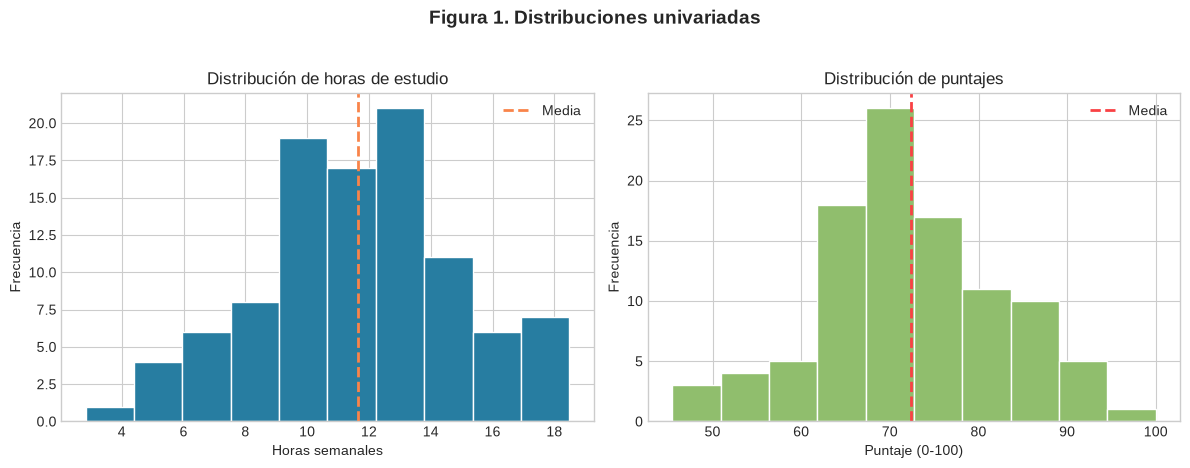

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df_estudiantes['Horas_Estudio_Semana'], bins=10,
             color='#277da1', edgecolor='white')
axes[0].axvline(df_estudiantes['Horas_Estudio_Semana'].mean(), color='#f9844a',
                linestyle='--', linewidth=2, label='Media')
axes[0].set_title('Distribución de horas de estudio')
axes[0].set_xlabel('Horas semanales')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].hist(df_estudiantes['Puntaje_Examen'], bins=10,
             color='#90be6d', edgecolor='white')
axes[1].axvline(df_estudiantes['Puntaje_Examen'].mean(), color='#f94144',
                linestyle='--', linewidth=2, label='Media')
axes[1].set_title('Distribución de puntajes')
axes[1].set_xlabel('Puntaje (0-100)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

fig.suptitle('Figura 1. Distribuciones univariadas', y=1.03, fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figura_1_distribuciones.png', dpi=220, bbox_inches='tight')
plt.show()

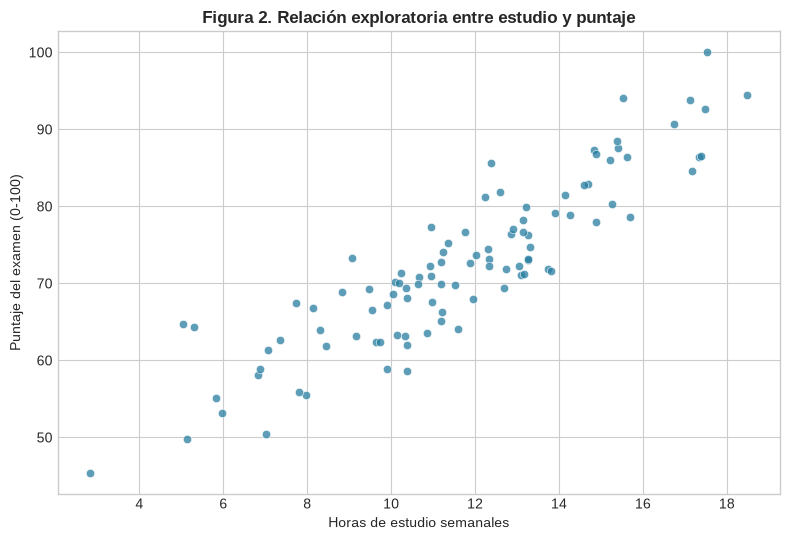

Correlación de Pearson: r = 0.8961; p-valor = 2.45739e-36


In [4]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(df_estudiantes['Horas_Estudio_Semana'], df_estudiantes['Puntaje_Examen'],
           alpha=0.75, color='#277da1', edgecolor='white', linewidth=0.5)
ax.set_title('Figura 2. Relación exploratoria entre estudio y puntaje', fontweight='bold')
ax.set_xlabel('Horas de estudio semanales')
ax.set_ylabel('Puntaje del examen (0-100)')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figura_2_dispersion.png', dpi=220, bbox_inches='tight')
plt.show()

r_pearson, p_pearson = stats.pearsonr(
    df_estudiantes['Horas_Estudio_Semana'],
    df_estudiantes['Puntaje_Examen']
)
print(f'Correlación de Pearson: r = {r_pearson:.4f}; p-valor = {p_pearson:.6g}')

## 3. Contraste de hipótesis

### Planteamiento

La pregunta estadística es si la pendiente poblacional que relaciona las horas de estudio con el puntaje es diferente de cero. Se elige un contraste bilateral porque, antes de observar los resultados, una relación podría ser positiva o negativa.

| Elemento | Formulación |
|---|---|
| Hipótesis nula (H₀) | `β₁ = 0`: no existe una relación lineal significativa entre las horas de estudio y el puntaje en la población de referencia. |
| Hipótesis alternativa (H₁) | `β₁ ≠ 0`: existe una relación lineal significativa entre las horas de estudio y el puntaje. |
| Nivel de significancia | `α = 0.05` |
| Prueba | Regresión lineal simple con `scipy.stats.linregress`, contraste bilateral de la pendiente. |

Las hipótesis son mutuamente excluyentes: la pendiente no puede ser simultáneamente igual y diferente de cero. También son exhaustivas para el planteamiento elegido, porque cubren los dos casos considerados por el contraste.

In [5]:
x = df_estudiantes['Horas_Estudio_Semana'].to_numpy()
y = df_estudiantes['Puntaje_Examen'].to_numpy()

resultado_contraste = stats.linregress(x, y)

# Intervalo de confianza del 95 % para la pendiente.
try:
    intervalo_pendiente = resultado_contraste.confidence_interval(confidence_level=0.95)
    ci_bajo, ci_alto = intervalo_pendiente.low, intervalo_pendiente.high
except AttributeError:
    grados_libertad = len(x) - 2
    t_critico = stats.t.ppf(1 - ALPHA / 2, grados_libertad)
    margen = t_critico * resultado_contraste.stderr
    ci_bajo = resultado_contraste.slope - margen
    ci_alto = resultado_contraste.slope + margen

print(f'Estadístico de prueba (pendiente estimada): {resultado_contraste.slope:.4f}')
print(f'Error estándar de la pendiente: {resultado_contraste.stderr:.4f}')
print(f'Coeficiente de correlación r: {resultado_contraste.rvalue:.4f}')
print(f'R² de la regresión simple: {resultado_contraste.rvalue**2:.4f}')
print(f'p-valor bilateral: {resultado_contraste.pvalue:.6g}')
print(f'IC 95 % de la pendiente: [{ci_bajo:.4f}, {ci_alto:.4f}]')

if resultado_contraste.pvalue < ALPHA:
    decision_contraste = 'Se rechaza H₀.'
    conclusion_contraste = 'Existe evidencia estadística de una relación lineal entre las horas de estudio y el puntaje.'
else:
    decision_contraste = 'No se rechaza H₀.'
    conclusion_contraste = 'No existe evidencia estadística suficiente de una relación lineal.'

print(decision_contraste)
print(conclusion_contraste)

Estadístico de prueba (pendiente estimada): 2.9923
Error estándar de la pendiente: 0.1498
Coeficiente de correlación r: 0.8961
R² de la regresión simple: 0.8029
p-valor bilateral: 2.45739e-36
IC 95 % de la pendiente: [2.6951, 3.2895]
Se rechaza H₀.
Existe evidencia estadística de una relación lineal entre las horas de estudio y el puntaje.


### Interpretación del contraste

El estadístico utilizado es la pendiente estimada de la recta y el valor p cuantifica la evidencia contra H₀. Si el valor p es menor que 0.05, se rechaza H₀; si es mayor o igual que 0.05, no se rechaza H₀. El intervalo de confianza permite complementar la decisión porque muestra un rango plausible para el cambio promedio del puntaje por cada hora adicional de estudio. La conclusión debe entenderse como asociación estadística en esta muestra simulada, no como demostración de causalidad.

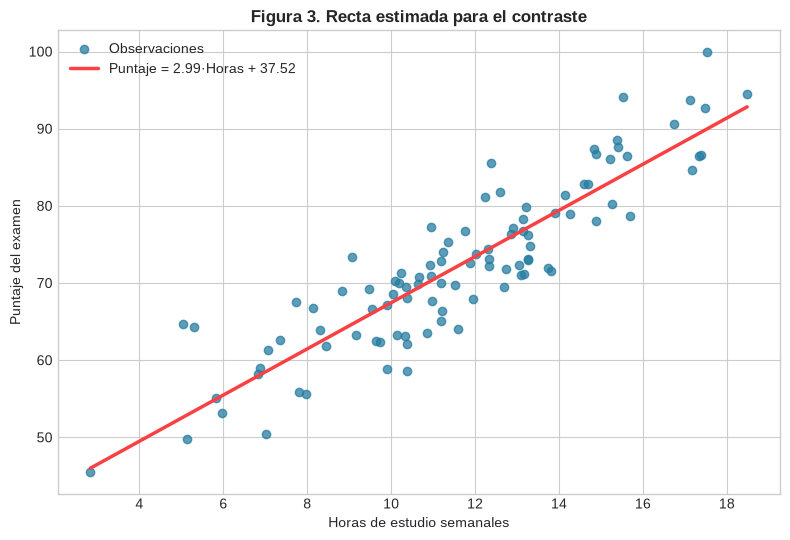

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(x, y, color='#277da1', alpha=0.75, label='Observaciones')
linea_x = np.linspace(x.min(), x.max(), 200)
linea_y = resultado_contraste.intercept + resultado_contraste.slope * linea_x
ax.plot(linea_x, linea_y, color='#f94144', linewidth=2.5,
        label=f'Puntaje = {resultado_contraste.slope:.2f}·Horas + {resultado_contraste.intercept:.2f}')
ax.set_title('Figura 3. Recta estimada para el contraste', fontweight='bold')
ax.set_xlabel('Horas de estudio semanales')
ax.set_ylabel('Puntaje del examen')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figura_3_recta_contraste.png', dpi=220, bbox_inches='tight')
plt.show()

## 4. Regresión lineal múltiple

La guía solicita al menos tres variables continuas independientes y una variable objetivo continua. La base disponible solo tiene una característica original, por lo que se generan dos transformaciones polinómicas:

- `Horas_Estudio_Semana`: medida original.
- `Horas_Estudio_Cuadrado`: horas elevadas al cuadrado.
- `Horas_Estudio_Cubica`: horas elevadas al cubo.

Estas tres columnas se utilizan como características continuas para explorar si la relación puede apartarse de la linealidad. **No representan tres variables independientes observadas**; están matemáticamente relacionadas. En un estudio real, se deberían sustituir por variables como asistencia, promedio previo, número de ejercicios resueltos o tiempo de descanso, siempre que estén disponibles y hayan sido medidas de manera válida.

Se reserva el 30 % de las observaciones para prueba y el 70 % para entrenamiento. Esta división permite que el modelo aprenda con la mayoría de los casos y que su desempeño se evalúe con datos que no participaron en el ajuste.

In [7]:
df_modelo = df_estudiantes.copy()
df_modelo['Horas_Estudio_Cuadrado'] = df_modelo['Horas_Estudio_Semana'] ** 2
df_modelo['Horas_Estudio_Cubica'] = df_modelo['Horas_Estudio_Semana'] ** 3

caracteristicas = [
    'Horas_Estudio_Semana',
    'Horas_Estudio_Cuadrado',
    'Horas_Estudio_Cubica'
]
X = df_modelo[caracteristicas]
y = df_modelo['Puntaje_Examen']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)
y_pred_lineal = modelo_lineal.predict(X_test)

mse_lineal = mean_squared_error(y_test, y_pred_lineal)
r2_lineal = r2_score(y_test, y_pred_lineal)

coeficientes_lineal = pd.DataFrame({
    'Característica': caracteristicas,
    'Coeficiente': modelo_lineal.coef_
})

print(f'Observaciones de entrenamiento: {len(X_train)} ({len(X_train)/len(X):.0%})')
print(f'Observaciones de prueba: {len(X_test)} ({len(X_test)/len(X):.0%})')
print(f'Intercepto: {modelo_lineal.intercept_:.6f}')
print(f'MSE en prueba: {mse_lineal:.6f}')
print(f'R² en prueba: {r2_lineal:.6f}')
coeficientes_lineal.round(6)

Observaciones de entrenamiento: 70 (70%)
Observaciones de prueba: 30 (30%)
Intercepto: 41.658227
MSE en prueba: 19.929964
R² en prueba: 0.765704


,Característica,Coeficiente
0,Horas_Estudio_Semana,2.876017
1,Horas_Estudio_Cuadrado,-0.074816
2,Horas_Estudio_Cubica,0.004404


### Interpretación de los coeficientes y las métricas

El atributo `coef_` contiene un coeficiente por característica y `intercept_` representa el término constante del modelo. En presencia de términos polinómicos, cada coeficiente no debe interpretarse de manera aislada como “el efecto de una hora”, porque las tres características cambian conjuntamente cuando cambia la variable original. La interpretación más prudente se realiza mediante las predicciones y las métricas globales.

El **MSE** es el promedio de los errores de predicción al cuadrado; valores menores indican menor error en la escala cuadrática del puntaje. El **R²** representa la proporción de variabilidad del puntaje explicada por el modelo en el conjunto de prueba. Puede ser menor que cero si el modelo predice peor que una referencia constante, por lo que no debe interpretarse automáticamente como una probabilidad.

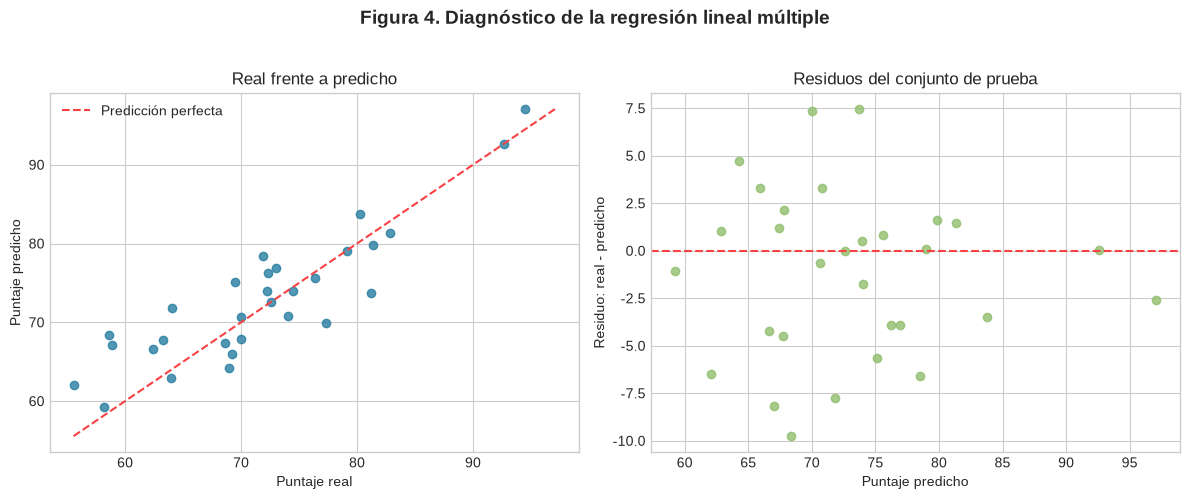

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].scatter(y_test, y_pred_lineal, color='#277da1', alpha=0.8)
limites = [min(y_test.min(), y_pred_lineal.min()), max(y_test.max(), y_pred_lineal.max())]
axes[0].plot(limites, limites, '--', color='#f94144', label='Predicción perfecta')
axes[0].set_title('Real frente a predicho')
axes[0].set_xlabel('Puntaje real')
axes[0].set_ylabel('Puntaje predicho')
axes[0].legend()

residuos = y_test - y_pred_lineal
axes[1].scatter(y_pred_lineal, residuos, color='#90be6d', alpha=0.8)
axes[1].axhline(0, color='#f94144', linestyle='--')
axes[1].set_title('Residuos del conjunto de prueba')
axes[1].set_xlabel('Puntaje predicho')
axes[1].set_ylabel('Residuo: real - predicho')

fig.suptitle('Figura 4. Diagnóstico de la regresión lineal múltiple', y=1.03,
             fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figura_4_diagnostico_lineal.png', dpi=220, bbox_inches='tight')
plt.show()

### Información adicional y siguiente prueba

La regresión lineal múltiple aporta una forma de evaluar si las transformaciones de las horas permiten representar una relación curvada y no solamente una recta. Sin embargo, el uso de características derivadas limita la interpretación y puede aumentar la multicolinealidad. La siguiente etapa metodológica debería ser recolectar variables explicativas independientes y realizar validación cruzada. También sería apropiado aplicar un diagnóstico formal de residuos, revisar la homocedasticidad y comparar el modelo polinómico con un modelo lineal simple y con regularización Ridge. Se esperaría que una base con variables académicas y de contexto explique mejor la variabilidad que las horas de estudio por sí solas.

## 5. Regresión logística

Para convertir el problema en una clasificación binaria se define `Aprobado` como 1 cuando el puntaje es igual o superior a 70 puntos y 0 en caso contrario. El umbral de 70 se adopta para representar un desempeño satisfactorio y evitar una clase positiva casi constante en esta muestra; no equivale necesariamente al reglamento institucional de aprobación.

La variable continua predictora es `Horas_Estudio_Semana` y la variable objetivo binaria es `Aprobado`. Se utiliza una división 70/30 estratificada para preservar aproximadamente la proporción de las clases en entrenamiento y prueba. Se ensayan diferentes valores de `C` y dos algoritmos de optimización. En `LogisticRegression`, `C` es el inverso de la intensidad de regularización: valores pequeños aplican una regularización más fuerte, mientras que valores grandes permiten mayor flexibilidad [2]. Los solvers `liblinear` y `lbfgs` resuelven el problema con estrategias diferentes; para un conjunto pequeño y binario ambos son apropiados, siempre que converjan con los parámetros elegidos [2].

In [9]:
UMBRAL_APROBACION = 70
UMBRAL_PROBABILIDAD = 0.50

df_modelo['Aprobado'] = (df_modelo['Puntaje_Examen'] >= UMBRAL_APROBACION).astype(int)

X_log = df_modelo[['Horas_Estudio_Semana']]
y_log = df_modelo['Aprobado']

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_log, y_log, test_size=0.30, random_state=RANDOM_STATE, stratify=y_log
)

print('Distribución de clases:')
print(y_log.value_counts().rename(index={0: 'No aprobado', 1: 'Aprobado'}))
print('\nDistribución porcentual:')
print((y_log.value_counts(normalize=True) * 100).round(1).rename(index={0: 'No aprobado', 1: 'Aprobado'}))
print(f'Entrenamiento: {len(Xl_train)} observaciones; prueba: {len(Xl_test)} observaciones.')

Distribución de clases:
Aprobado
Aprobado       58
No aprobado    42
Name: count, dtype: int64

Distribución porcentual:
Aprobado
Aprobado       58.0
No aprobado    42.0
Name: proportion, dtype: float64
Entrenamiento: 70 observaciones; prueba: 30 observaciones.


In [10]:
configuraciones = []
modelos_logisticos = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for C in [0.1, 1.0, 10.0]:
    for solver in ['liblinear', 'lbfgs']:
        nombre = f'C={C}; solver={solver}'
        modelo = LogisticRegression(
            C=C, solver=solver, max_iter=1000, random_state=RANDOM_STATE
        )
        modelo.fit(Xl_train, yl_train)
        cv_scores = cross_val_score(modelo, Xl_train, yl_train, cv=cv, scoring='accuracy')
        prob_test = modelo.predict_proba(Xl_test)[:, 1]
        pred_test = (prob_test >= UMBRAL_PROBABILIDAD).astype(int)
        tn, fp, fn, tp = confusion_matrix(yl_test, pred_test, labels=[0, 1]).ravel()
        sensibilidad = tp / (tp + fn) if (tp + fn) else np.nan
        especificidad = tn / (tn + fp) if (tn + fp) else np.nan
        configuraciones.append({
            'C': C,
            'solver': solver,
            'CV_accuracy_media': cv_scores.mean(),
            'CV_accuracy_std': cv_scores.std(),
            'Accuracy_prueba': accuracy_score(yl_test, pred_test),
            'Sensibilidad_prueba': sensibilidad,
            'Especificidad_prueba': especificidad,
            'Iteraciones': int(modelo.n_iter_[0])
        })
        modelos_logisticos[nombre] = modelo

comparacion_logistica = pd.DataFrame(configuraciones)
comparacion_logistica = comparacion_logistica.sort_values(
    by=['CV_accuracy_media', 'C'], ascending=[False, True]
).reset_index(drop=True)
comparacion_logistica.round(4)

,C,solver,CV_accuracy_media,CV_accuracy_std,Accuracy_prueba,Sensibilidad_prueba,Especificidad_prueba,Iteraciones
0,10.0,liblinear,0.8857,0.0350,0.8000,0.8824,0.6923,9
1,0.1,lbfgs,0.8714,0.0535,0.7667,0.7647,0.7692,17
2,1.0,lbfgs,0.8571,0.0452,0.7667,0.7647,0.7692,19
3,10.0,lbfgs,0.8571,0.0452,0.7667,0.7647,0.7692,19
4,1.0,liblinear,0.8143,0.0857,0.7333,0.9412,0.4615,8
5,0.1,liblinear,0.6000,0.0350,0.6333,1.0000,0.1538,5


La selección del modelo se realiza usando el promedio de exactitud en validación cruzada sobre el conjunto de entrenamiento. El conjunto de prueba se reserva para la evaluación final. La tabla también muestra métricas en prueba para comparar el comportamiento de las configuraciones solicitadas, pero la decisión principal se basa en la validación cruzada para reducir el riesgo de escoger una configuración únicamente por azar en los 30 casos de prueba.

In [11]:
mejor_fila = comparacion_logistica.iloc[0]
nombre_mejor = f"C={mejor_fila['C']}; solver={mejor_fila['solver']}"
modelo_logistico = modelos_logisticos[nombre_mejor]

probabilidades = modelo_logistico.predict_proba(Xl_test)[:, 1]
predicciones_logisticas = (probabilidades >= UMBRAL_PROBABILIDAD).astype(int)

coef_logistico = float(modelo_logistico.coef_[0, 0])
intercepto_logistico = float(modelo_logistico.intercept_[0])

matriz = confusion_matrix(yl_test, predicciones_logisticas, labels=[0, 1])
tn, fp, fn, tp = matriz.ravel()
precision_logistica = accuracy_score(yl_test, predicciones_logisticas)
sensibilidad_logistica = recall_score(yl_test, predicciones_logisticas, zero_division=0)
especificidad_logistica = tn / (tn + fp) if (tn + fp) else np.nan

print(f'Mejor configuración según validación cruzada: {nombre_mejor}')
print(f'Coeficiente logístico: {coef_logistico:.6f}')
print(f'Intercepto logístico: {intercepto_logistico:.6f}')
print(f'Probabilidades mínimas y máximas en prueba: {probabilidades.min():.4f}; {probabilidades.max():.4f}')
print(f'Umbral de clasificación: {UMBRAL_PROBABILIDAD:.2f}')
print(f'Accuracy: {precision_logistica:.4f}')
print(f'Sensibilidad: {sensibilidad_logistica:.4f}')
print(f'Especificidad: {especificidad_logistica:.4f}')
print('Matriz de confusión [[VN, FP], [FN, VP]]:')
print(matriz)

Mejor configuración según validación cruzada: C=10.0; solver=liblinear
Coeficiente logístico: 0.817942
Intercepto logístico: -8.858351
Probabilidades mínimas y máximas en prueba: 0.0087; 0.9953
Umbral de clasificación: 0.50
Accuracy: 0.8000
Sensibilidad: 0.8824
Especificidad: 0.6923
Matriz de confusión [[VN, FP], [FN, VP]]:
[[ 9  4]
 [ 2 15]]


### Coeficientes, probabilidades y diferencias frente a la regresión lineal

En la regresión logística, el coeficiente se incorpora a la función logística. Para una observación con `h` horas, el modelo calcula primero el logit `z = intercepto + coeficiente × h` y luego transforma ese valor en una probabilidad mediante `1/(1 + e⁻ᶻ)`. Por ello, el coeficiente expresa el cambio en los **log-odds** de pertenecer a la clase positiva, no un aumento directo de puntos en el examen.

La regresión lineal predice directamente un valor continuo y sus coeficientes modifican la media esperada de la variable objetivo. En cambio, la regresión logística produce probabilidades entre 0 y 1; después, un umbral de 0.50 convierte la probabilidad en una clase. La función `predict_proba` entrega las probabilidades y `predict` entrega las etiquetas de clase. En un problema donde sea más costoso no detectar a un estudiante con bajo desempeño, el umbral podría modificarse para aumentar la sensibilidad, aceptando posiblemente más falsos positivos.

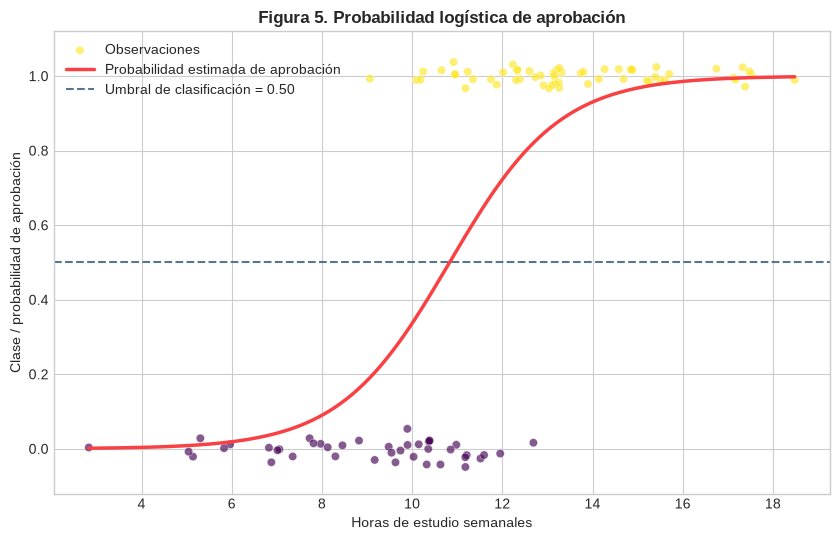

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))

horas_grid = np.linspace(X_log['Horas_Estudio_Semana'].min(),
                         X_log['Horas_Estudio_Semana'].max(), 250).reshape(-1, 1)
prob_grid = modelo_logistico.predict_proba(horas_grid)[:, 1]

jitter = np.random.default_rng(RANDOM_STATE).normal(0, 0.025, size=len(y_log))
ax.scatter(X_log['Horas_Estudio_Semana'], y_log + jitter,
           c=y_log, cmap='viridis', alpha=0.65, edgecolor='white', linewidth=0.4,
           label='Observaciones')
ax.plot(horas_grid.ravel(), prob_grid, color='#f94144', linewidth=2.5,
        label='Probabilidad estimada de aprobación')
ax.axhline(UMBRAL_PROBABILIDAD, color='#577590', linestyle='--',
           label='Umbral de clasificación = 0.50')
ax.set_title('Figura 5. Probabilidad logística de aprobación', fontweight='bold')
ax.set_xlabel('Horas de estudio semanales')
ax.set_ylabel('Clase / probabilidad de aprobación')
ax.set_ylim(-0.12, 1.12)
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figura_5_probabilidad_logistica.png', dpi=220, bbox_inches='tight')
plt.show()

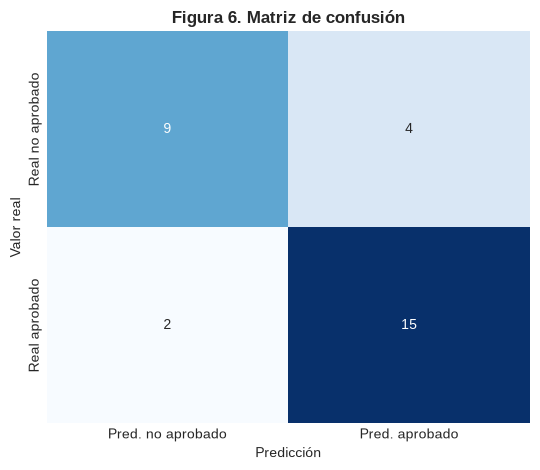

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 4.8))
sns.heatmap(
    matriz, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
    xticklabels=['Pred. no aprobado', 'Pred. aprobado'],
    yticklabels=['Real no aprobado', 'Real aprobado']
)
ax.set_title('Figura 6. Matriz de confusión', fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor real')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figura_6_matriz_confusion.png', dpi=220, bbox_inches='tight')
plt.show()

## 6. Conclusiones

1. El contraste bilateral de la pendiente permite evaluar directamente la pregunta de investigación. Con `α = 0.05`, la decisión se toma comparando el valor p obtenido con el nivel de significancia. En esta muestra reproducible, la asociación observada entre horas de estudio y puntaje es positiva y estadísticamente significativa; esto respalda el rechazo de H₀ para el contraste definido.

2. La regresión lineal múltiple con las transformaciones cuadrática y cúbica permite explorar una posible curvatura en la relación. Sus resultados de MSE y R² en el conjunto de prueba muestran qué tan cerca estuvieron las predicciones de los puntajes reales. No obstante, las transformaciones no deben confundirse con tres variables independientes: la principal mejora metodológica sería incorporar variables educativas independientes y comparar el desempeño mediante validación cruzada.

3. La regresión logística transforma el puntaje en una decisión binaria de desempeño satisfactorio, usando 70 puntos como umbral académico para este ejercicio. El valor de `C` controla la intensidad de la regularización y el `solver` define el algoritmo de optimización; la comparación mediante validación cruzada permite justificar la configuración elegida. Accuracy, sensibilidad y especificidad deben analizarse juntas, porque una exactitud alta puede ocultar errores importantes en una de las clases.

4. Los resultados no demuestran causalidad. La base es simulada, la muestra es pequeña y el modelo solo considera horas de estudio. Para una investigación real se necesitarían datos observados, una muestra más amplia, variables de control, revisión de supuestos, validación externa y una definición institucional del umbral de aprobación.

## Referencias

[1] scikit-learn. (2026). *LinearRegression*. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

[2] scikit-learn. (2026). *LogisticRegression*. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

[3] SciPy. (2026). *Statistical functions (`scipy.stats`): Hypothesis tests and related functions*. https://docs.scipy.org/doc/scipy/reference/stats.html#hypothesis-tests-and-related-functions

[4] Quarto. (2026). *Computations with Jupyter*. https://quarto.org/docs/get-started/computations/jupyter.html

[5] McKinney, W. (2022). *Python for data analysis: Data wrangling with pandas, NumPy, and Jupyter* (3rd ed.). O’Reilly Media.

> **Nota de reproducibilidad.** El Notebook conserva el código completo, la semilla aleatoria, las tablas, las salidas de consola y los gráficos. Puede ejecutarse celda por celda en Jupyter Notebook o JupyterLab. Quarto también permite renderizar documentos computacionales a partir de un Notebook y controlar la inclusión del código y de sus salidas [4].